<a href="https://colab.research.google.com/github/iav2002/AppliedDeepLearning/blob/main/Part3_2_TransferAutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3.2 - Transfer Learning from Autoencoder

Take the encoder from notebook 9, attach a classification head, train on Block 2 for age category prediction. Run twice, once with the encoder frozen and once fine tuned end to end. Compare against notebook 8.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/Colab Notebooks/AppliedDL/face_age.zip" /content/
!cp -r "/content/drive/MyDrive/Colab Notebooks/AppliedDL/data_splits" /content/
!unzip -q /content/face_age.zip -d /content/

## 2. Imports

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA A100-SXM4-40GB


## 3. Split Block 2 for classification

Block 2 split 80/20 train/val, stratified by age_category to keep class balance close to the original.

In [4]:
b2 = pd.read_csv("/content/data_splits/block2.csv")
b2_train, b2_val = train_test_split(
    b2, test_size=0.2, stratify=b2["age_category"], random_state=42
)
b2_train.to_csv("/content/b2_train.csv", index=False)
b2_val.to_csv("/content/b2_val.csv", index=False)
print(f"block2 total {len(b2)}  train {len(b2_train)}  val {len(b2_val)}")
print(b2["age_category"].value_counts())

block2 total 4392  train 3513  val 879
age_category
infant    959
youth     731
mature    616
mid       588
senior    583
child     506
teen      409
Name: count, dtype: int64


## 4. Architecture

Same encoder shape as notebook 9 so we can load the pretrained weights. Head matches the BestModel head from notebook 8, flatten + linear 80000 → 128, ReLU, dropout, linear to 7 classes.

In [5]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size, padding=pad)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size, padding=pad)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.proj = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        identity = self.proj(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + identity)
        out = self.pool(out)
        return out

In [6]:
class Classifier(nn.Module):
    def __init__(self, kernel_size=3, n_classes=7):
        super().__init__()
        # encoder, same shape as notebook 9 autoencoder, so we can load those weights
        self.encoder = nn.Sequential(
            ResBlock(3, 32, kernel_size),
            ResBlock(32, 64, kernel_size),
            ResBlock(64, 128, kernel_size),
        )
        # head, same as BestModel head from notebook 8
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 25 * 25, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.head(x)
        return x


m = Classifier().to(device)
n_params = sum(p.numel() for p in m.parameters())
n_enc = sum(p.numel() for p in m.encoder.parameters())
n_head = sum(p.numel() for p in m.head.parameters())
print(f"total {n_params:,}  encoder {n_enc:,}  head {n_head:,}")

x = torch.randn(2, 3, 200, 200).to(device)
print(f"output {tuple(m(x).shape)}")

total 10,539,495  encoder 298,464  head 10,241,031
output (2, 7)


## 5. Data

Same FaceAgeDataset as notebook 8, classification task. Augmentation on train, clean transform on val. ImageNet normalisation.

In [7]:
CATEGORIES = ["infant", "child", "teen", "youth", "mid", "mature", "senior"]
CAT_TO_IDX = {c: i for i, c in enumerate(CATEGORIES)}


class FaceAgeDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"/content/{row['path']}").convert("RGB")
        if self.transform:
            img = self.transform(img)
        lbl = torch.tensor(CAT_TO_IDX[row["age_category"]], dtype=torch.long)
        return img, lbl

In [8]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

tf_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

tf_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [9]:
train_ds = FaceAgeDataset("/content/b2_train.csv", transform=tf_train)
val_ds = FaceAgeDataset("/content/b2_val.csv", transform=tf_val)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)

print(f"train batches {len(train_loader)}  val batches {len(val_loader)}")
imgs, lbls = next(iter(train_loader))
print(f"batch shape {tuple(imgs.shape)}  labels shape {tuple(lbls.shape)}")

train batches 55  val batches 14
batch shape (64, 3, 200, 200)  labels shape (64,)


## 6. Train and eval functions

Standard classification pattern. run_variant takes a parameter group as input so we can train either the full model or just the head.

In [14]:
def train_one_epoch(model, loader, loss_fn, optimizer, scheduler=None):
    model.train()
    total = 0
    n = 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = loss_fn(preds, lbls)
        loss.backward()
        optimizer.step()
        total += loss.item() * imgs.size(0)
        n += imgs.size(0)
    if scheduler is not None:
        scheduler.step()
    return total / n


def evaluate(model, loader, loss_fn):
    model.eval()
    total = 0
    n = 0
    correct = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds = model(imgs)
            loss = loss_fn(preds, lbls)
            total += loss.item() * imgs.size(0)
            n += imgs.size(0)
            correct += (preds.argmax(1) == lbls).sum().item()
    return total / n, correct / n

## 7. Load pretrained encoder

Read the saved autoencoder file once, copy the encoder state into the classifier in each run.

In [11]:
ae = torch.load("/content/drive/MyDrive/Colab Notebooks/AppliedDL/models/ae_block1.pt", map_location=device)
print(f"loaded autoencoder, val mse {ae['val_mse']:.4f}, arch {ae['arch']}")

loaded autoencoder, val mse 0.0082, arch resblock_x3_ch3_32_64_128


## 8. Run 1, frozen encoder

Encoder weights kept fixed, only the head trains. This measures how good the autoencoder features are on their own without any task-specific tuning.

In [13]:
m_frozen = Classifier().to(device)
m_frozen.encoder.load_state_dict(ae["encoder_state"])

for p in m_frozen.encoder.parameters():
    p.requires_grad = False

n_train = sum(p.numel() for p in m_frozen.parameters() if p.requires_grad)
print(f"trainable params {n_train:,}", flush=True)

# inline training loop instead of run_variant, so prints are direct, bugged before
loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.AdamW(m_frozen.head.parameters(), lr=1e-3, weight_decay=1e-4)
max_epochs = 20
patience = 5
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs, eta_min=1e-5)

best_acc = -1.0
best_state = None
hist = {"train": [], "val_loss": [], "val_acc": []}
no_improve = 0

t0 = time.time()
for epoch in range(max_epochs):
    tr = train_one_epoch(m_frozen, train_loader, loss_fn, opt, sched)
    vl, va = evaluate(m_frozen, val_loader, loss_fn)
    hist["train"].append(tr)
    hist["val_loss"].append(vl)
    hist["val_acc"].append(va)
    print(f"epoch {epoch+1:2d}  train {tr:.4f}  val {vl:.4f}  acc {va:.4f}", flush=True)

    if va > best_acc:
        best_acc = va
        best_state = {k: v.clone() for k, v in m_frozen.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"early stop at epoch {epoch+1}", flush=True)
            break

print(f"best acc {best_acc:.4f}  time {time.time() - t0:.1f}s", flush=True)
out_frozen = {"best_acc": best_acc, "best_state": best_state, "hist": hist}

trainable params 10,241,031
epoch  1  train 9.0895  val 1.7537  acc 0.3185
epoch  2  train 1.7553  val 1.6361  acc 0.3311
epoch  3  train 1.6896  val 1.6078  acc 0.3231
epoch  4  train 1.6683  val 1.5821  acc 0.3436
epoch  5  train 1.6483  val 1.5920  acc 0.3493
epoch  6  train 1.6619  val 1.5523  acc 0.3458
epoch  7  train 1.6284  val 1.5481  acc 0.3436
epoch  8  train 1.6321  val 1.5597  acc 0.3345
epoch  9  train 1.6283  val 1.5558  acc 0.3720
epoch 10  train 1.6139  val 1.5257  acc 0.3572
epoch 11  train 1.6125  val 1.5173  acc 0.3549
epoch 12  train 1.6036  val 1.5157  acc 0.3549
epoch 13  train 1.5940  val 1.5112  acc 0.3561
epoch 14  train 1.5946  val 1.5128  acc 0.3675
early stop at epoch 14
best acc 0.3720  time 130.3s


## 9. Run 2, fine tune

All parameters update together, encoder starts from autoencoder weights but is free to adapt during training.

In [15]:
m_ft = Classifier().to(device)
m_ft.encoder.load_state_dict(ae["encoder_state"])

n_train = sum(p.numel() for p in m_ft.parameters() if p.requires_grad)
print(f"trainable params {n_train:,}", flush=True)

loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.AdamW(m_ft.parameters(), lr=1e-3, weight_decay=1e-4)
max_epochs = 30
patience = 8
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs, eta_min=1e-5)

best_acc = -1.0
best_state = None
hist = {"train": [], "val_loss": [], "val_acc": []}
no_improve = 0

t0 = time.time()
for epoch in range(max_epochs):
    tr = train_one_epoch(m_ft, train_loader, loss_fn, opt, sched)
    vl, va = evaluate(m_ft, val_loader, loss_fn)
    hist["train"].append(tr)
    hist["val_loss"].append(vl)
    hist["val_acc"].append(va)
    print(f"epoch {epoch+1:2d}  train {tr:.4f}  val {vl:.4f}  acc {va:.4f}", flush=True)

    if va > best_acc:
        best_acc = va
        best_state = {k: v.clone() for k, v in m_ft.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"early stop at epoch {epoch+1}", flush=True)
            break

print(f"best acc {best_acc:.4f}  time {time.time() - t0:.1f}s", flush=True)
out_ft = {"best_acc": best_acc, "best_state": best_state, "hist": hist}

trainable params 10,539,495
epoch  1  train 9.7933  val 1.8780  acc 0.2821
epoch  2  train 1.8672  val 1.7879  acc 0.3026
epoch  3  train 1.7292  val 1.5934  acc 0.4084
epoch  4  train 1.5980  val 1.4548  acc 0.4516
epoch  5  train 1.5090  val 1.3679  acc 0.4608
epoch  6  train 1.4306  val 1.3013  acc 0.4664
epoch  7  train 1.3531  val 1.2796  acc 0.4812
epoch  8  train 1.3220  val 1.1774  acc 0.5381
epoch  9  train 1.2827  val 1.1621  acc 0.5415
epoch 10  train 1.2187  val 1.0990  acc 0.5791
epoch 11  train 1.1817  val 1.0288  acc 0.5802
epoch 12  train 1.1461  val 1.0584  acc 0.5654
epoch 13  train 1.1502  val 1.1210  acc 0.5518
epoch 14  train 1.1179  val 1.0282  acc 0.5802
epoch 15  train 1.0889  val 1.0218  acc 0.5870
epoch 16  train 1.0414  val 0.9874  acc 0.6086
epoch 17  train 1.0194  val 1.0565  acc 0.5848
epoch 18  train 0.9902  val 0.9983  acc 0.5973
epoch 19  train 0.9994  val 0.9539  acc 0.6189
epoch 20  train 0.9788  val 0.9281  acc 0.6143
epoch 21  train 0.9483  val 0.93

## 10. Comparison

Val accuracy across epochs for both runs against the best model so far

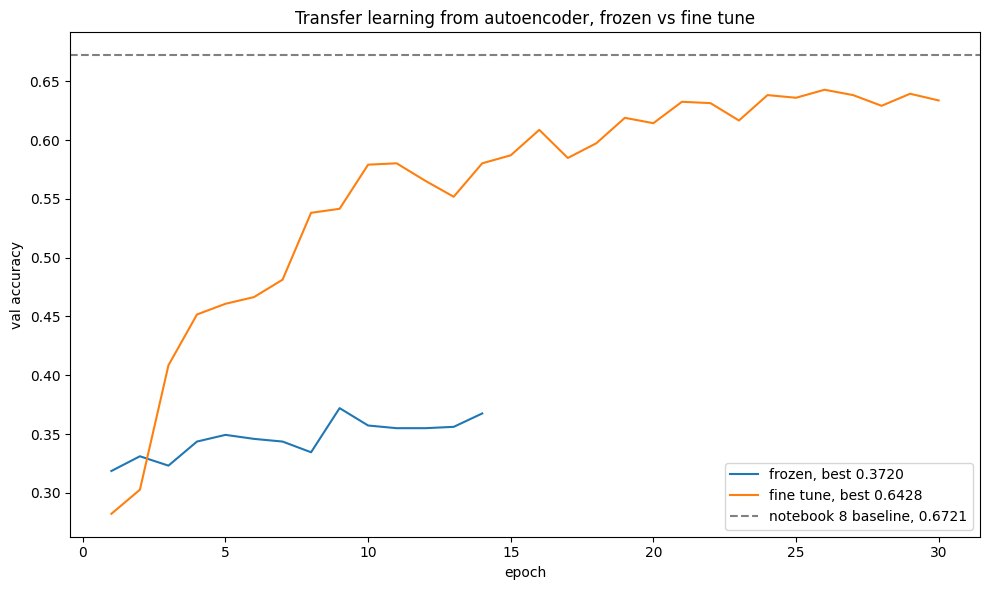


frozen     0.3720
fine tune  0.6428
baseline   0.6721 (notebook 8, full Part 2 training set)


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

ep_frozen = range(1, len(out_frozen["hist"]["val_acc"]) + 1)
ep_ft = range(1, len(out_ft["hist"]["val_acc"]) + 1)

ax.plot(ep_frozen, out_frozen["hist"]["val_acc"], label=f"frozen, best {out_frozen['best_acc']:.4f}")
ax.plot(ep_ft, out_ft["hist"]["val_acc"], label=f"fine tune, best {out_ft['best_acc']:.4f}")
ax.axhline(0.6721, linestyle="--", color="gray", label="notebook 8 baseline, 0.6721")
ax.set_xlabel("epoch")
ax.set_ylabel("val accuracy")
ax.set_title("Transfer learning from autoencoder, frozen vs fine tune")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nfrozen     {out_frozen['best_acc']:.4f}")
print(f"fine tune  {out_ft['best_acc']:.4f}")
print(f"baseline   0.6721 (notebook 8)")

## 11. Save best model



In [ ]:
import os
os.makedirs("/content/models", exist_ok=True)

torch.save({
    "state_dict": out_ft["best_state"],
    "task": "classification",
    "arch": "resblock_x3_pretrained_ae_finetuned",
    "kernel_size": 3,
    "val_acc": out_ft["best_acc"],
    "hist": out_ft["hist"],
}, "/content/models/transfer_ae.pt")

!cp /content/models/transfer_ae.pt "/content/drive/MyDrive/Colab Notebooks/AppliedDL/models/"
print("saved")